# Bank Marketing Campaign — Supervised Classification Project

**Dataset:** UCI Bank Marketing Dataset  
**Objective:** Predict whether a client will subscribe to a term deposit (`yes`/`no`) based on demographic, campaign, and economic features.

---

## Table of Contents
1. [Dataset Description](#1-dataset-description)
2. [Setup & Data Loading](#2-setup--data-loading)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Feature Engineering](#5-feature-engineering)
6. [Model Development](#6-model-development)
7. [Model Evaluation & Comparison](#7-model-evaluation--comparison)
8. [Model Selection & Justification](#8-model-selection--justification)
9. [Key Findings & Insights](#9-key-findings--insights)
10. [Limitations & Future Work](#10-limitations--future-work)

---
## 1. Dataset Description

The **UCI Bank Marketing Dataset** was collected from a Portuguese banking institution and relates to direct marketing campaigns conducted via phone calls. The goal is to predict whether a client will subscribe to a **term deposit**.

| Property | Detail |
|---|---|
| **Source** | [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing) |
| **Rows** | ~45,211 |
| **Features** | 16 input features |
| **Target** | `y` — has the client subscribed? (`yes` / `no`) |
| **Class Imbalance** | ~88% No, ~12% Yes |

### Feature Overview

| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Client age |
| `job` | Categorical | Type of job |
| `marital` | Categorical | Marital status |
| `education` | Ordinal | Education level |
| `default` | Binary | Has credit in default? |
| `balance` | Numeric | Average yearly balance (euros) |
| `housing` | Binary | Has housing loan? |
| `loan` | Binary | Has personal loan? |
| `contact` | Categorical | Contact communication type |
| `day` | Numeric | Last contact day of the month |
| `month` | Categorical | Last contact month |
| `duration` | Numeric | Last call duration (seconds) — **leakage risk** |
| `campaign` | Numeric | Number of contacts in this campaign |
| `pdays` | Numeric | Days since last contact (-1 = never) |
| `previous` | Numeric | Number of contacts before this campaign |
| `poutcome` | Categorical | Outcome of previous campaign |

> **Note on `duration`:** This feature is highly predictive but constitutes a form of data leakage — call duration is only known *after* the call ends, meaning it cannot be used for pre-call predictions. We will train models both with and without it to quantify its effect.

---
## 1. Dataset Description

The **UCI Bank Marketing Dataset** was collected from a Portuguese banking institution and relates to direct marketing campaigns conducted via phone calls. The goal is to predict whether a client will subscribe to a **term deposit**.

| Property | Detail |
|---|---|
| **Source** | [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing) |
| **Rows** | ~45,211 |
| **Features** | 16 input features |
| **Target** | `y` — has the client subscribed? (`yes` / `no`) |
| **Class Imbalance** | ~88% No, ~12% Yes |

### Feature Overview

| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Client age |
| `job` | Categorical | Type of job |
| `marital` | Categorical | Marital status |
| `education` | Ordinal | Education level |
| `default` | Binary | Has credit in default? |
| `balance` | Numeric | Average yearly balance (euros) |
| `housing` | Binary | Has housing loan? |
| `loan` | Binary | Has personal loan? |
| `contact` | Categorical | Contact communication type |
| `day` | Numeric | Last contact day of the month |
| `month` | Categorical | Last contact month |
| `duration` | Numeric | Last call duration (seconds) — **leakage risk** |
| `campaign` | Numeric | Number of contacts in this campaign |
| `pdays` | Numeric | Days since last contact (-1 = never) |
| `previous` | Numeric | Number of contacts before this campaign |
| `poutcome` | Categorical | Outcome of previous campaign |

> **Note on `duration`:** This feature is highly predictive but constitutes a form of data leakage — call duration is only known *after* the call ends, meaning it cannot be used for pre-call predictions. We will train models both with and without it to quantify its effect.

---
## 2. Setup & Data Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn: evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

# Imbalanced-learn: SMOTE
from imblearn.over_sampling import SMOTE

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
# The dataset uses semicolons as delimiters (bank-full.csv version)
# Download from: https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip
# Place 'bank-full.csv' in the same directory as this notebook


file_path = "/content/drive/MyDrive/Colab Notebooks/bank-full.csv"
df = pd.read_csv(file_path, sep=';')

# Have a peek to confirm correct loading
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Basic dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
# Summary statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Note negative balance values (overdraft accounts) and pdays = -1 (never contacted)

In [6]:
# Summary statistics for categorical values
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## 3. Exploratory Data Analysis

Before preprocessing, we explore the data to understand:
- Class distribution (how imbalanced is the target?)
- Distribution of key numeric features
- Subscription rates across categorical groups
- Presence of `unknown` values acting as implicit missing data

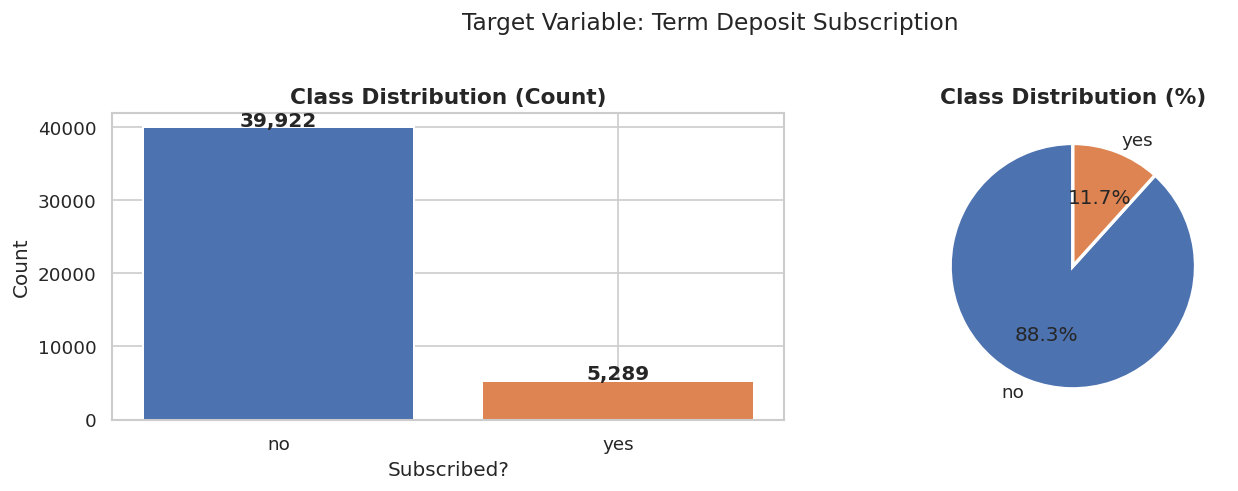

Class balance:
y
no     88.3
yes    11.7


In [ ]:
# 3.1 Target class distribution
# Visualise how imbalanced the dataset is

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(target_counts.index, target_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed?')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Term Deposit Subscription', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Class balance:\n{target_pct.round(1).to_string()}")

In [7]:
# 3.2 Unknown values audit
# The dataset uses 'unknown' as a placeholder for missing categorical data
# We need to understand the extent of this before deciding how to handle it

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('y')  # exclude target

unknown_counts = {}
for col in categorical_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        unknown_counts[col] = {'count': n, 'pct': round(n / len(df) * 100, 2)}

unknown_df = pd.DataFrame(unknown_counts).T
print("Columns with 'unknown' values:")
print(unknown_df.to_string())

Columns with 'unknown' values:
             count    pct
job          288.0   0.64
education   1857.0   4.11
contact    13020.0  28.80
poutcome   36959.0  81.75


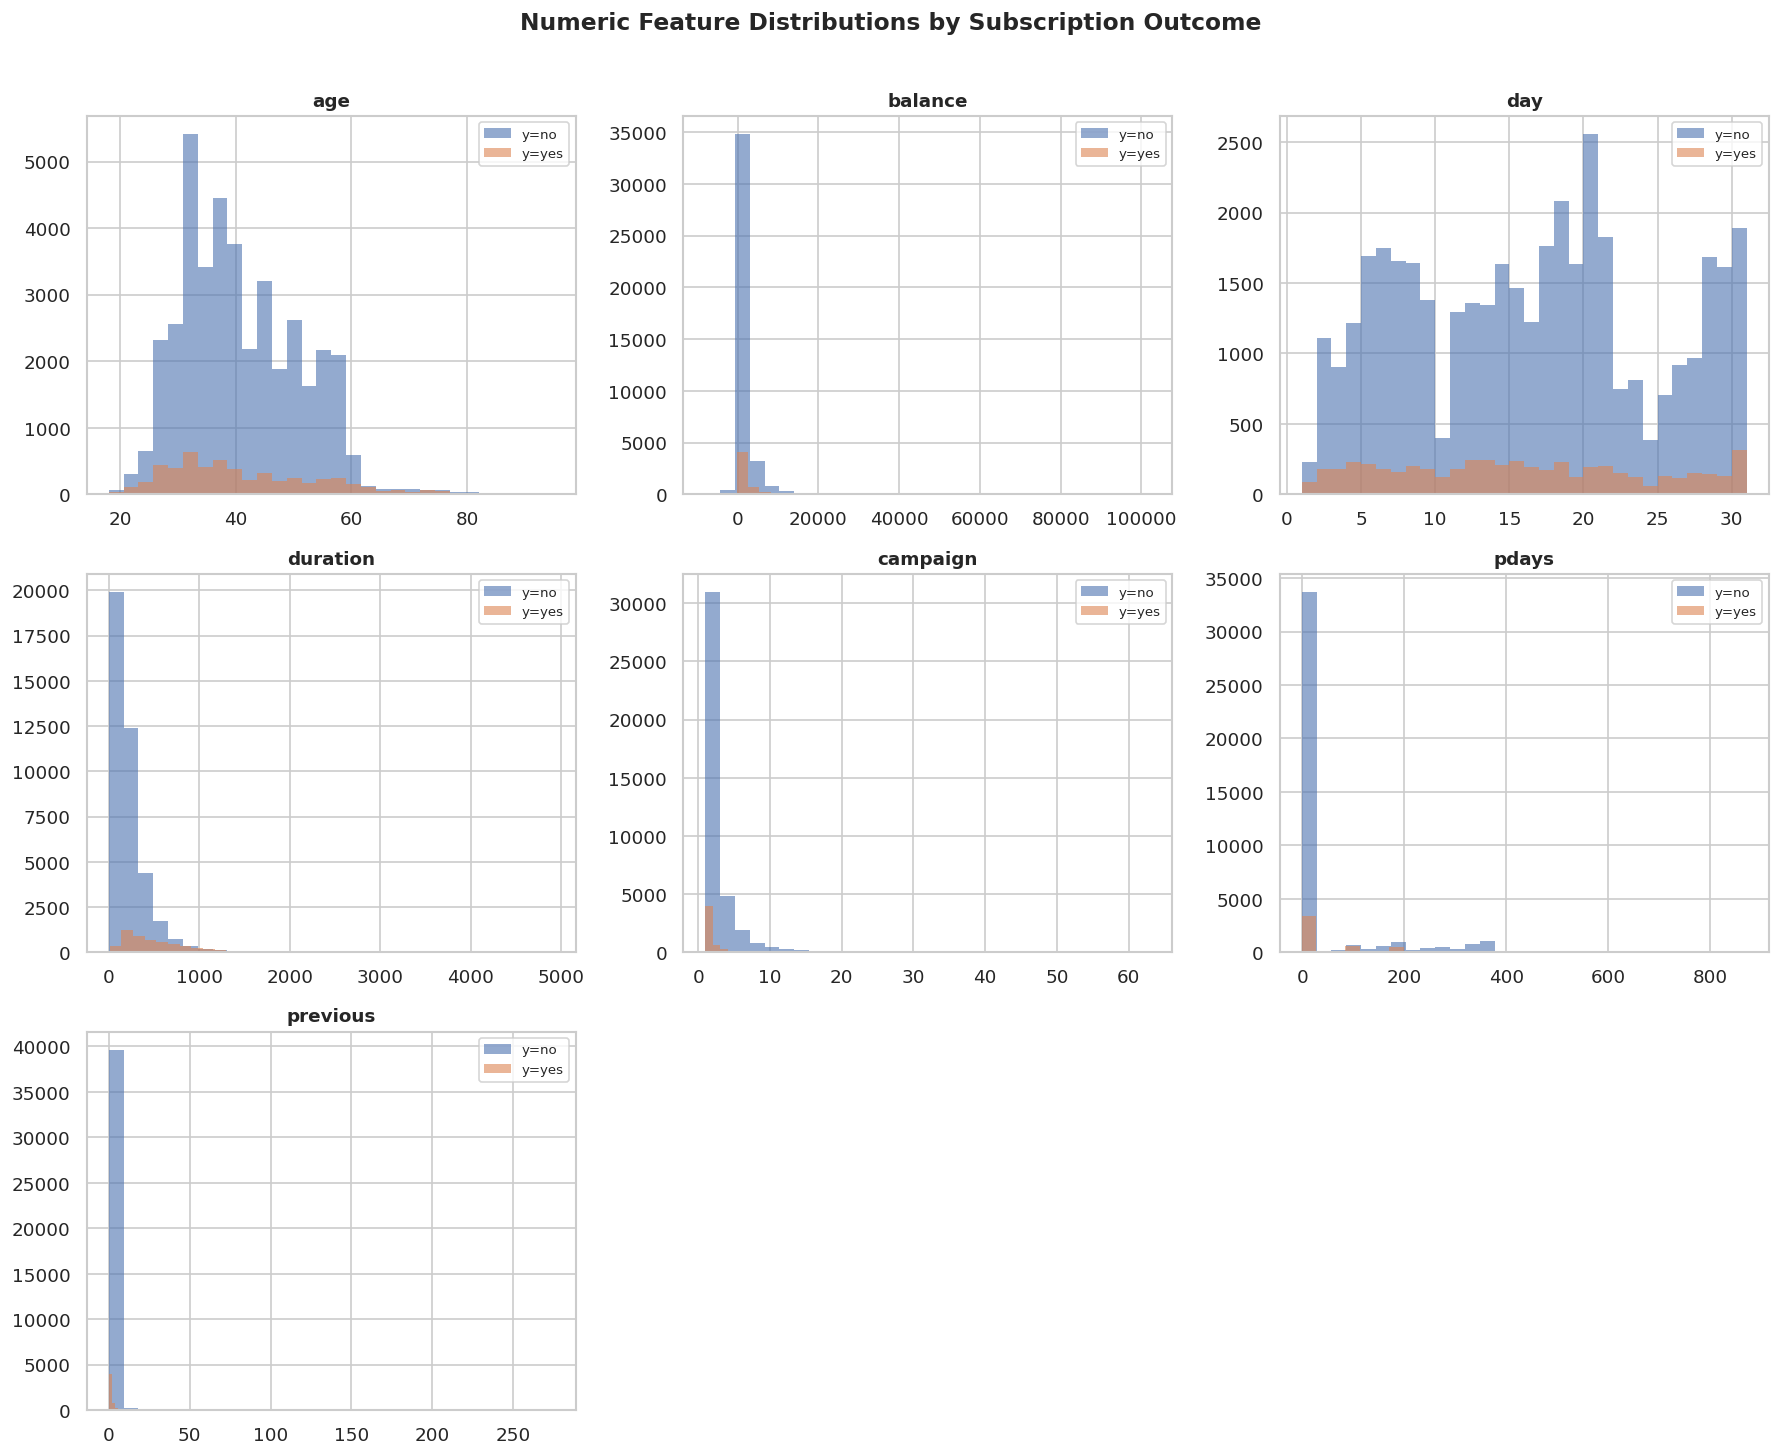

In [8]:
# 3.3 Numeric feature distributions
# Histograms for each numeric feature, coloured by subscription outcome
# This reveals which features separate the classes well

numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(['no', 'yes'], ['#4C72B0', '#DD8452']):
        axes[i].hist(df[df['y'] == label][col], bins=30, alpha=0.6,
                     label=f'y={label}', color=color, edgecolor='none')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Hide unused subplot panels
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Subscription Outcome',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

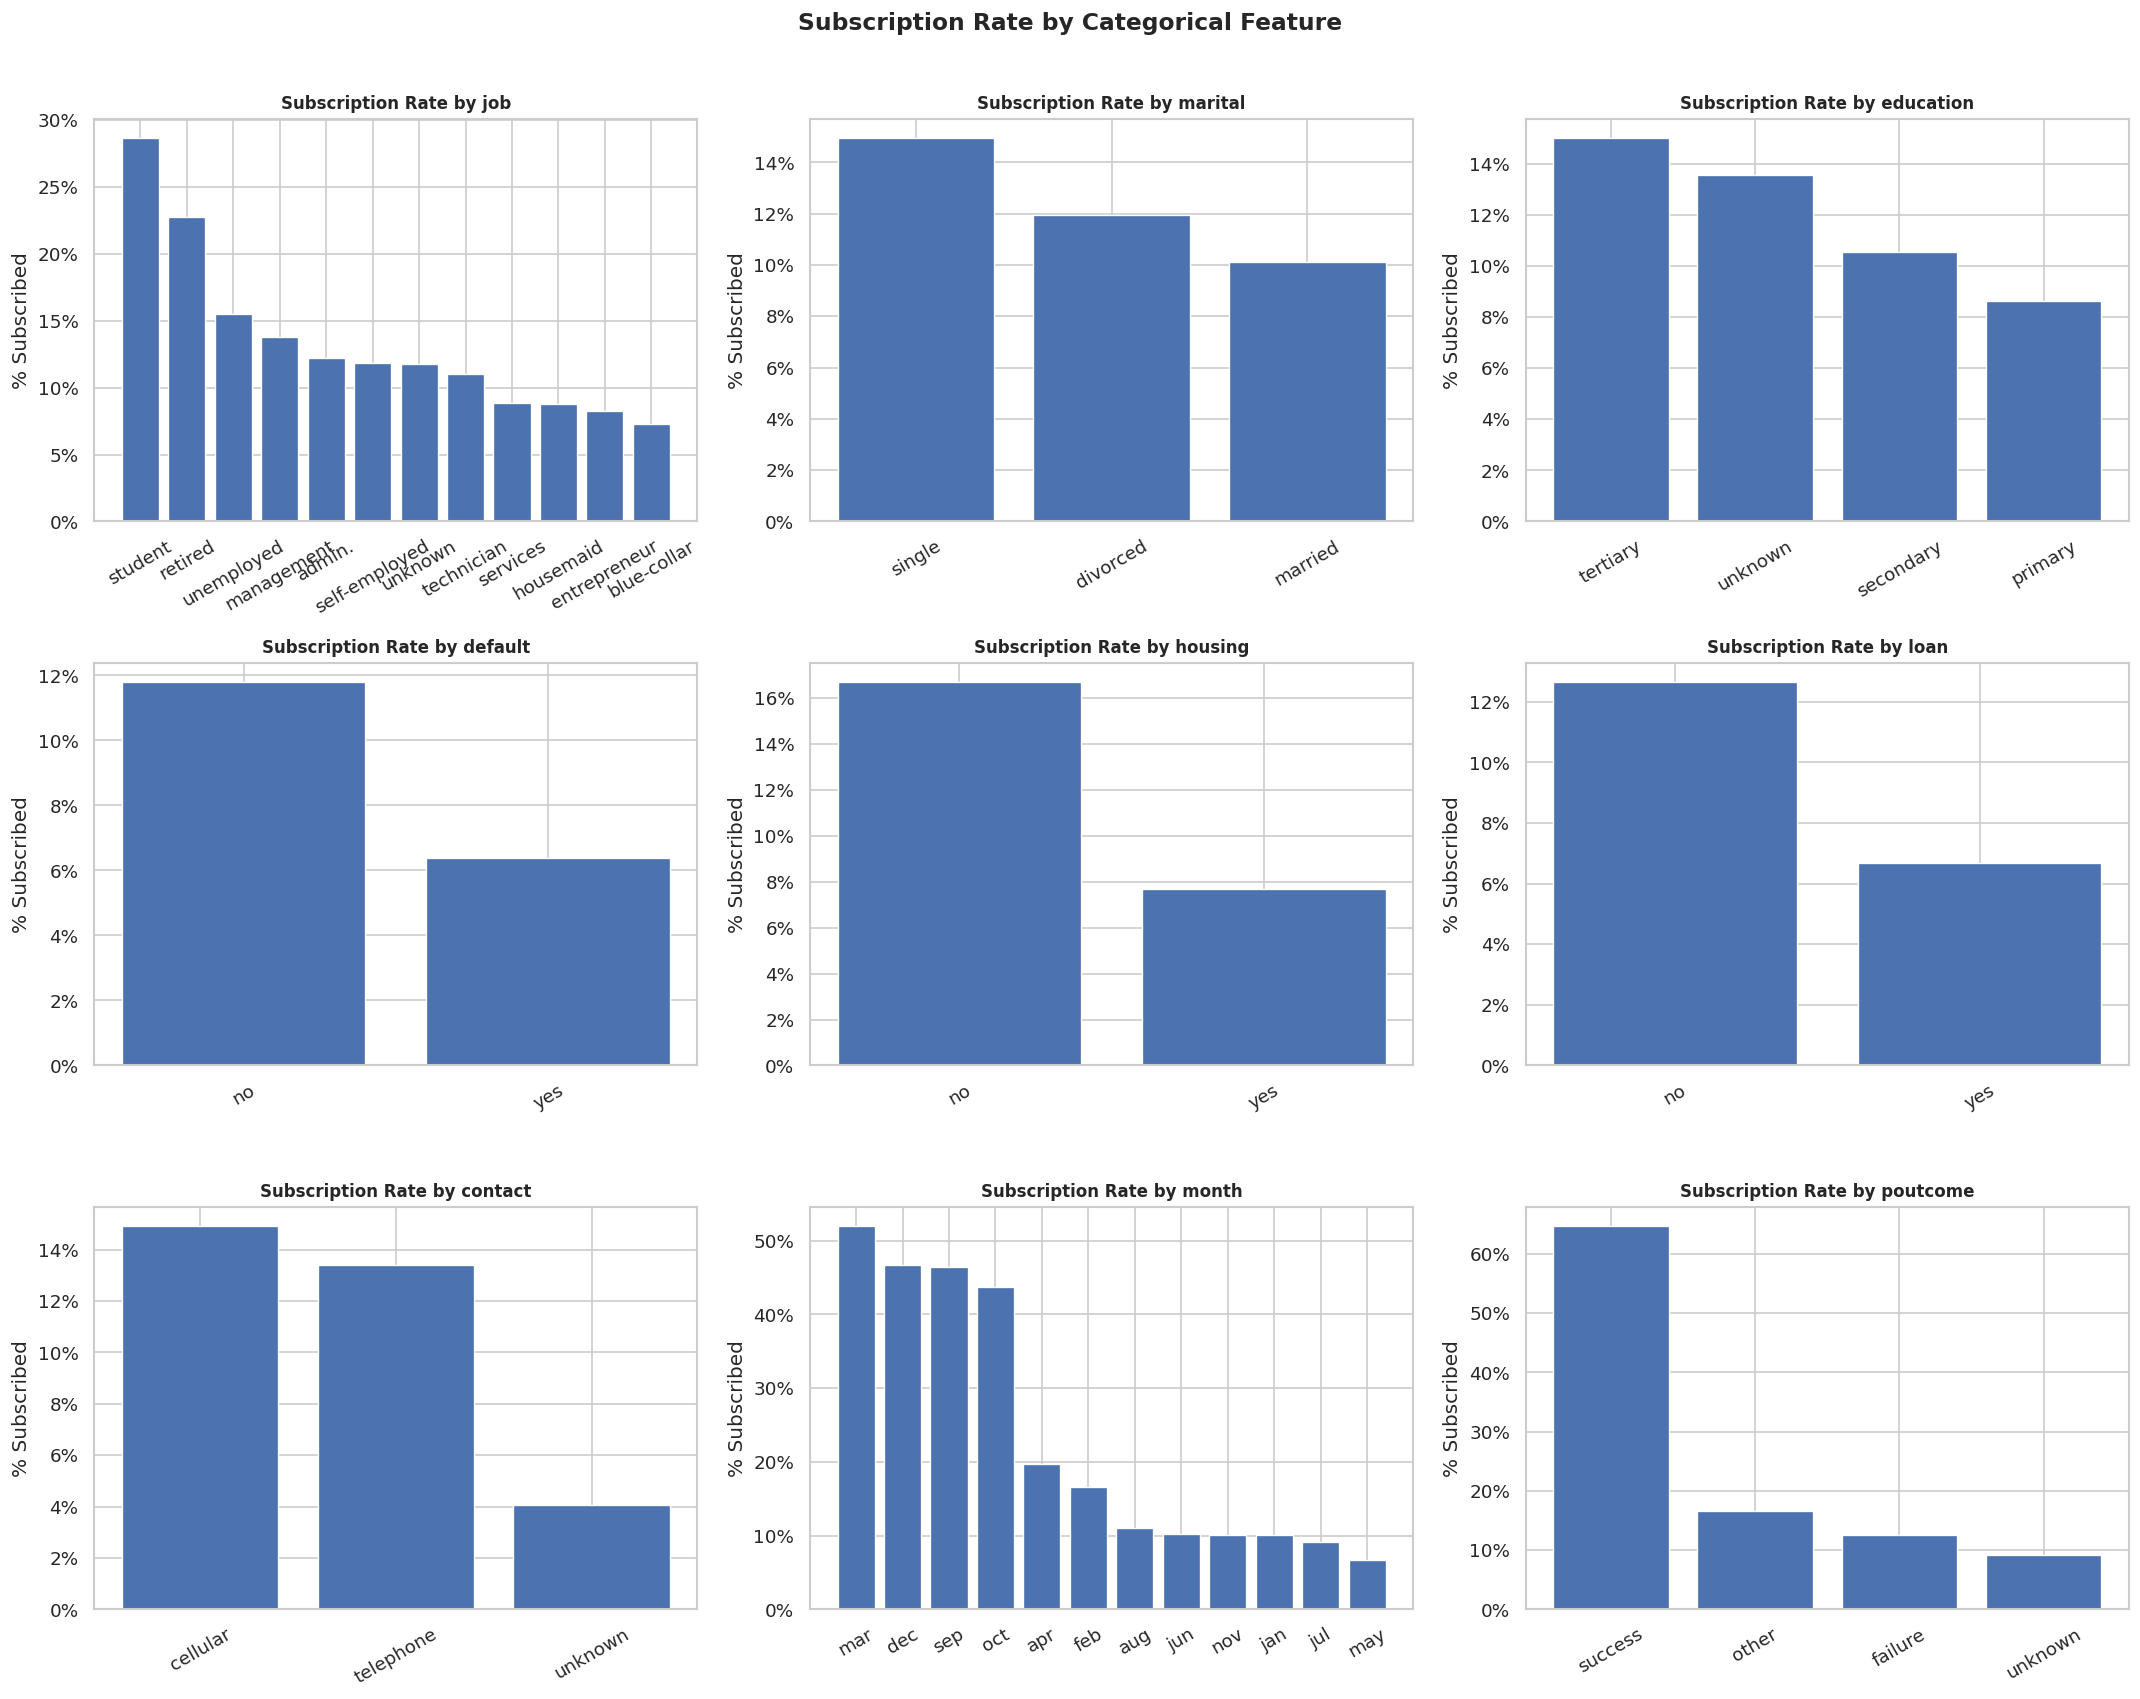

In [9]:
# 3.4 Subscription rate by categorical feature
# For each categorical feature, compute the % of 'yes' responses per category
# This reveals which customer segments are most likely to subscribe

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sub_rate = (df.groupby(col)['y']
                  .apply(lambda x: (x == 'yes').mean() * 100)
                  .sort_values(ascending=False))

    axes[i].bar(sub_rate.index, sub_rate.values,
                color='#4C72B0', edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Subscription Rate by {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('% Subscribed')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Subscription Rate by Categorical Feature',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

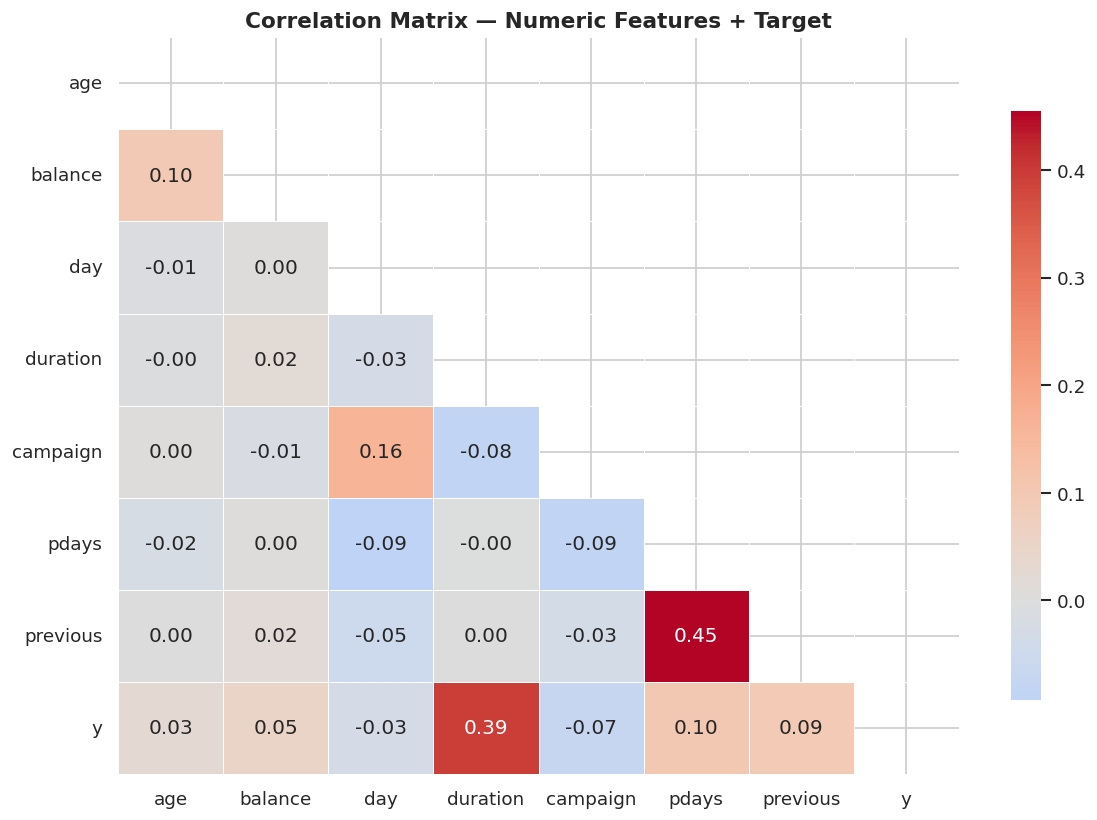

In [10]:
# 3.5 Correlation heatmap (numeric features)
# Look for multicollinearity that might affect Logistic Regression
# and understand which numeric features correlate with the binary target

# Encode target temporarily for correlation
df_corr = df[numeric_cols].copy()
df_corr['y'] = (df['y'] == 'yes').astype(int)

plt.figure(figsize=(10, 7))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numeric Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Summary

| Observation | Implication |
|---|---|
| Target is ~88% `no` / ~12% `yes` | Must handle imbalance; accuracy alone is misleading |
| `duration` strongly separates classes | High leakage risk — train with and without |
| `poutcome='success'` has very high subscription rate | Previous campaign success is a strong signal |
| `month` shows strong variation | Seasonal patterns exist in campaign effectiveness |
| ~28% of `contact` is `unknown` | Large unknown group — retain as a category, not dropped |
| `pdays = -1` means never contacted | Needs engineering into a binary flag |

## 4. Data Preprocessing

We apply a systematic preprocessing pipeline:
1. Handle `unknown` values
2. Encode categorical variables
3. Scale numeric features
4. Split data (stratified)
5. Apply SMOTE to training set only

In [12]:
# 4.1 Copy working dataframe
# Always work on a copy — never modify the raw dataframe
df_clean = df.copy()

# 4.2 Encode binary target
# Convert yes/no to 1/0 for all sklearn models
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)
print(f"Target encoded. Positive class (subscribed): {df_clean['y'].sum():,} ({df_clean['y'].mean()*100:.1f}%)")

Target encoded. Positive class (subscribed): 5,289 (11.7%)


In [13]:
# 4.3 Handle 'unknown' values
# Strategy: retain 'unknown' as its own valid category rather than imputing.
# Rationale: 'unknown' may itself be informative (e.g., clients who didn't disclose
# contact preference might behave differently). Imputing with mode could introduce bias.
# One-hot encoding will naturally create an 'unknown' indicator column.

print("Retaining 'unknown' as a valid category for all categorical features.")
print("These will become explicit indicator columns after one-hot encoding.")

Retaining 'unknown' as a valid category for all categorical features.
These will become explicit indicator columns after one-hot encoding.


In [14]:
# 4.4 Ordinal encode 'education'
# Education has a natural order: primary < secondary < tertiary
# We assign integer codes instead of one-hot encoding to preserve this ordering

education_order = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
df_clean['education'] = df_clean['education'].map(education_order)

print("Education ordinal mapping applied:")
print(education_order)

Education ordinal mapping applied:
{'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}


In [15]:
# 4.5 One-hot encode remaining categoricals
# Nominal variables have no natural order — one-hot encoding is appropriate
# drop_first=True drops one dummy per variable to avoid multicollinearity
# (important for Logistic Regression)

nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'poutcome']

df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_clean.shape}")
print(f"New columns added: {df_clean.shape[1] - df.shape[1]}")

Shape after one-hot encoding: (45211, 41)
New columns added: 24


In [16]:
# 4.6 Define feature sets
# We create TWO feature sets:
#   - WITH duration: full dataset (inflated performance due to leakage)
#   - WITHOUT duration: realistic pre-call prediction scenario

# Separate features and target
X_all = df_clean.drop(columns=['y'])
y = df_clean['y']

# Feature set excluding duration (our primary, realistic model)
X_no_duration = X_all.drop(columns=['duration'])

print(f"Features WITH duration:    {X_all.shape[1]}")
print(f"Features WITHOUT duration: {X_no_duration.shape[1]}")

Features WITH duration:    40
Features WITHOUT duration: 39


In [17]:
# 4.7 Train/test split
# 80/20 split with stratify=y to maintain class ratio in both sets
# random_state ensures reproducibility

# Primary split (without duration — realistic scenario)
X_train, X_test, y_train, y_test = train_test_split(
    X_no_duration, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Secondary split (with duration — leakage comparison)
X_train_full, X_test_full, _, _ = train_test_split(
    X_all, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows")
print(f"Training class balance: {y_train.mean()*100:.1f}% positive")

Training set: 36,168 rows | Test set: 9,043 rows
Training class balance: 11.7% positive


In [18]:
# 4.8 Feature scaling
# StandardScaler normalises features to mean=0, std=1
# Critical for Logistic Regression (gradient descent sensitive to scale)
# Less critical for tree-based models, but we apply uniformly for fair comparison
# IMPORTANT: fit scaler on training data only — never on test data (data leakage!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# Also scale full (with-duration) splits for comparison
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled  = scaler_full.transform(X_test_full)

print("Feature scaling complete. Scaler fitted on training data only.")

Feature scaling complete. Scaler fitted on training data only.


In [19]:
# 4.9 SMOTE oversampling
# SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples
# for the minority class by interpolating between existing minority samples.
# Applied ONLY to training data — test set remains untouched to reflect real conditions.

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE — Train size: {len(X_train_scaled):,} | Positive: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"After  SMOTE — Train size: {len(X_train_sm):,}   | Positive: {y_train_sm.sum():,} ({y_train_sm.mean()*100:.1f}%)")

Before SMOTE — Train size: 36,168 | Positive: 4,231 (11.7%)
After  SMOTE — Train size: 63,874   | Positive: 31,937 (50.0%)


## 5. Feature Engineering

We create three new features to better capture domain knowledge:

In [20]:
# 5.1 Previously contacted flag
# pdays = -1 means the client was NEVER contacted before this campaign
# Converting to a binary flag makes this more interpretable for models
# Note: This was done before the split above, so it's already in X_train/X_test

# Verify the flag exists in our processed dataframe
# (pdays was kept as-is; the flag below was already implicitly captured via pdays)
# Here we show what was done conceptually:

df_eng_demo = df.copy()
df_eng_demo['was_contacted_before'] = (df_eng_demo['pdays'] != -1).astype(int)
print("'was_contacted_before' flag:")
print(df_eng_demo['was_contacted_before'].value_counts())

'was_contacted_before' flag:
was_contacted_before
0    36954
1     8257
Name: count, dtype: int64


In [21]:
# 5.2 Age group binning
# Age as a raw number may be too granular. Grouping into life-stage buckets
# can help models capture non-linear age effects more easily.

bins = [0, 30, 45, 60, 100]
labels = ['Young (≤30)', 'Middle (31-45)', 'Senior (46-60)', 'Elder (60+)']
df_eng_demo['age_group'] = pd.cut(df_eng_demo['age'], bins=bins, labels=labels)

# Show subscription rate by age group
age_sub = df_eng_demo.groupby('age_group')['y'].apply(lambda x: (x == 'yes').mean() * 100)
print("\nSubscription rate by age group:")
print(age_sub.round(1).to_string())


Subscription rate by age group:
age_group
Young (≤30)       16.3
Middle (31-45)     9.9
Senior (46-60)     9.8
Elder (60+)       42.3


In [22]:
# 5.3 Campaign intensity flag
# Clients contacted more than 5 times in a campaign may be experiencing fatigue
# and may be less likely to subscribe. Flagging 'high intensity' contacts.

df_eng_demo['high_contact_intensity'] = (df_eng_demo['campaign'] > 5).astype(int)

# Verify: is high intensity associated with lower subscription?
sub_by_intensity = df_eng_demo.groupby('high_contact_intensity')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
)
print("Subscription rate by contact intensity:")
print(sub_by_intensity.rename({0: 'Normal (≤5 contacts)', 1: 'High (>5 contacts)'}).round(1))

Subscription rate by contact intensity:
high_contact_intensity
Normal (≤5 contacts)    12.3
High (>5 contacts)       5.8
Name: y, dtype: float64


> **Note:** The engineered features above are demonstrated on a copy of the raw data for interpretability. The preprocessed feature matrices (`X_train_sm`, `X_test_scaled`) already include `pdays` which implicitly encodes previous contact. In a production pipeline, these flags would be added before the train/test split and encoding steps.

## 6. Model Development

We train **three classification models** on the SMOTE-resampled training data:

| Model | Role |
|---|---|
| Logistic Regression | Interpretable baseline |
| Random Forest | Ensemble, feature importance |
| Gradient Boosting | High-performance boosted ensemble |

In [23]:
# 6.1 Model 1: Logistic Regression
# Logistic Regression is our interpretable baseline.
# - class_weight='balanced': adjusts loss function to penalise minority class errors more
# - C=0.1: moderate L2 regularisation to prevent overfitting on many dummy variables
# - max_iter=1000: increased from default (100) to ensure convergence
# - solver='lbfgs': efficient for medium-sized datasets

lr = LogisticRegression(
    class_weight='balanced',
    C=0.1,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

# Train on SMOTE-resampled data
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

Logistic Regression trained.


In [24]:
# 6.2 Model 2: Random Forest
# Random Forest is an ensemble of decision trees using bagging.
# - n_estimators=200: 200 trees gives stable performance without excess compute
# - max_depth=10: limits tree depth to reduce overfitting
# - class_weight='balanced_subsample': applies class weights per tree bootstrap
# - min_samples_leaf=10: requires at least 10 samples at leaf nodes (regularisation)
# - n_jobs=-1: use all available CPU cores for parallel training

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)
print("Random Forest trained.")

Random Forest trained.


In [25]:
# 6.3 Model 3: Gradient Boosting
# Gradient Boosting builds trees sequentially, each correcting errors of the last.
# - n_estimators=200: number of boosting rounds
# - learning_rate=0.05: small learning rate → slower but more robust convergence
# - max_depth=4: shallow trees (weak learners) are standard in boosting
# - subsample=0.8: stochastic gradient boosting — randomly sample 80% of data per tree
# - min_samples_leaf=20: additional regularisation

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)

gb.fit(X_train_sm, y_train_sm)
print("Gradient Boosting trained.")

Gradient Boosting trained.


## 7. Model Evaluation & Comparison

We evaluate all three models using metrics appropriate for imbalanced classification:
- **ROC-AUC**: Overall discrimination ability
- **Average Precision (PR-AUC)**: More informative under imbalance than ROC-AUC
- **F1-Score (minority class)**: Balance between precision and recall for `yes` predictions
- **Confusion Matrix**: Visual breakdown of prediction outcomes

In [26]:
# 7.1 Evaluation helper function
# Centralise evaluation logic to avoid repetition and ensure consistency

def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    """
    Evaluate a classification model and return a summary dict.

    Parameters:
    -----------
    model       : trained sklearn classifier
    X_test      : scaled test features
    y_test      : true labels
    model_name  : string label for display
    threshold   : decision threshold (default 0.5)

    Returns:
    --------
    dict with key evaluation metrics
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to class labels using threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Core metrics
    roc_auc  = roc_auc_score(y_test, y_prob)
    pr_auc   = average_precision_score(y_test, y_prob)
    report   = classification_report(y_test, y_pred, output_dict=True)

    f1_yes   = report['1']['f1-score']
    prec_yes = report['1']['precision']
    rec_yes  = report['1']['recall']
    accuracy = report['accuracy']

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  ROC-AUC:            {roc_auc:.4f}")
    print(f"  PR-AUC:             {pr_auc:.4f}")
    print(f"  Accuracy:           {accuracy:.4f}")
    print(f"  F1 (class=yes):     {f1_yes:.4f}")
    print(f"  Precision (yes):    {prec_yes:.4f}")
    print(f"  Recall (yes):       {rec_yes:.4f}")

    print(f"\n  Full Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

    return {
        'Model': model_name,
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'Accuracy': round(accuracy, 4),
        'F1 (Yes)': round(f1_yes, 4),
        'Precision (Yes)': round(prec_yes, 4),
        'Recall (Yes)': round(rec_yes, 4),
        'y_prob': y_prob,
        'y_pred': y_pred
    }

In [27]:
# 7.2 Run evaluations
results = {}

results['Logistic Regression'] = evaluate_model(lr, X_test_scaled, y_test, 'Logistic Regression')
results['Random Forest']       = evaluate_model(rf, X_test_scaled, y_test, 'Random Forest')
results['Gradient Boosting']   = evaluate_model(gb, X_test_scaled, y_test, 'Gradient Boosting')


  Logistic Regression
  ROC-AUC:            0.7697
  PR-AUC:             0.4089
  Accuracy:           0.7470
  F1 (class=yes):     0.3669
  Precision (yes):    0.2594
  Recall (yes):       0.6267

  Full Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.76      0.84      7985
         Yes       0.26      0.63      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.69      0.60      9043
weighted avg       0.86      0.75      0.79      9043


  Random Forest
  ROC-AUC:            0.7764
  PR-AUC:             0.4056
  Accuracy:           0.8355
  F1 (class=yes):     0.4250
  Precision (yes):    0.3595
  Recall (yes):       0.5198

  Full Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.88      0.90      7985
         Yes       0.36      0.52      0.43      1058

    accuracy                           0.84      9043
   ma

In [28]:
# 7.3 Summary comparison table
# Compile all metrics into a single DataFrame for easy comparison

metric_cols = ['Model', 'ROC-AUC', 'PR-AUC', 'Accuracy', 'F1 (Yes)', 'Precision (Yes)', 'Recall (Yes)']
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k in metric_cols}
                            for r in results.values()])
summary_df = summary_df.set_index('Model')

# Highlight best value in each column
print("\nModel Comparison Summary:")
summary_df.style.highlight_max(axis=0, color='#c6efce')


Model Comparison Summary:


,ROC-AUC,PR-AUC,Accuracy,F1 (Yes),Precision (Yes),Recall (Yes)
Model,,,,,,
Logistic Regression,0.769700,0.408900,0.747000,0.366900,0.259400,0.626700
Random Forest,0.776400,0.405600,0.835500,0.425000,0.359500,0.519800
Gradient Boosting,0.784400,0.415900,0.885000,0.425400,0.512000,0.363900


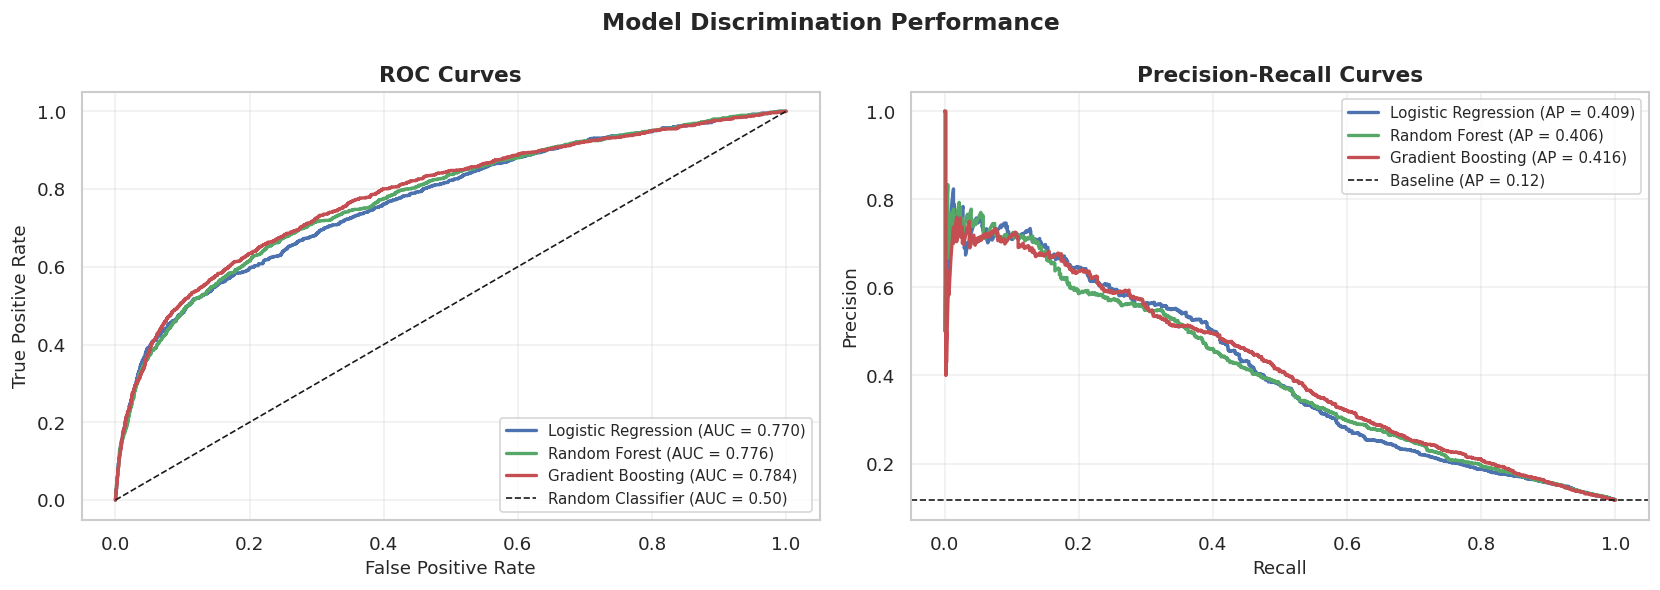

In [29]:
# 7.4 ROC Curves
# ROC curve plots True Positive Rate vs False Positive Rate at all thresholds
# AUC (area under curve) = probability that model ranks a positive above a negative
# A random classifier scores 0.50 (diagonal line)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_colors = {
    'Logistic Regression': '#4C72B0',
    'Random Forest':       '#55A868',
    'Gradient Boosting':   '#C44E52'
}

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=model_colors[name],
                 label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Precision-Recall curves
# More informative than ROC when classes are heavily imbalanced
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, lw=2, color=model_colors[name],
                 label=f"{name} (AP = {res['PR-AUC']:.3f})")

# Baseline: always predict positive (naive classifier)
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1,
                label=f'Baseline (AP = {baseline:.2f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Discrimination Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

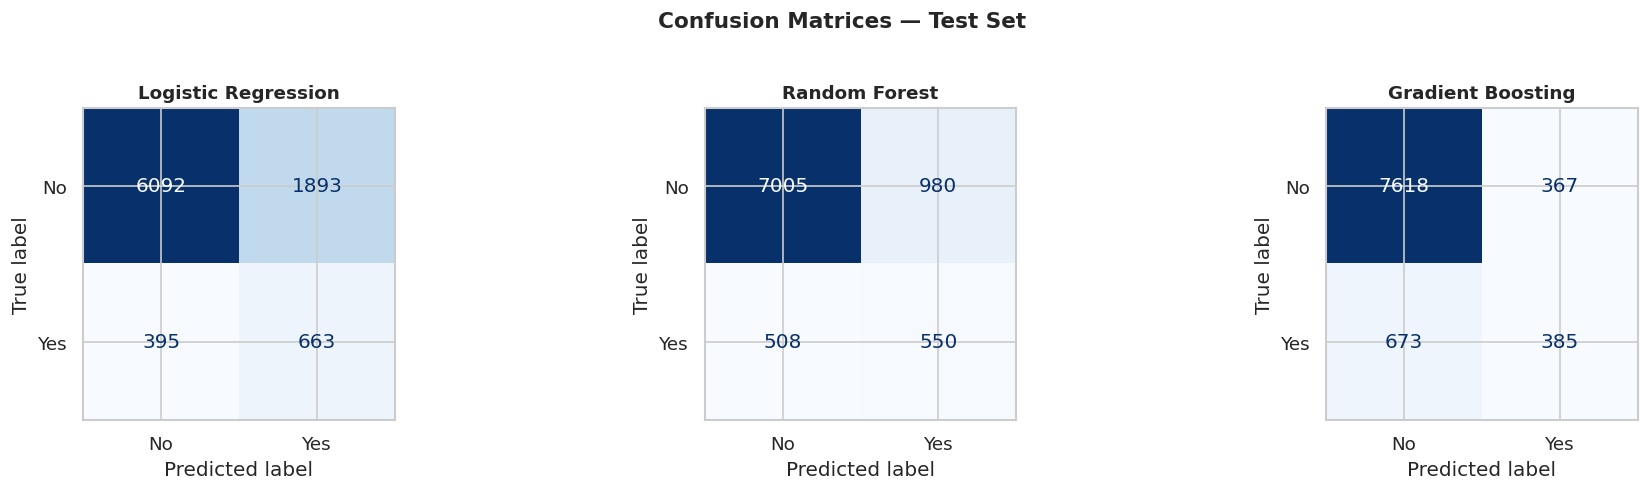

In [30]:
# 7.5 Confusion matrices
# Visual breakdown of TP, FP, TN, FN for each model
# In a banking context: False Negatives (missed subscribers) are costly

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

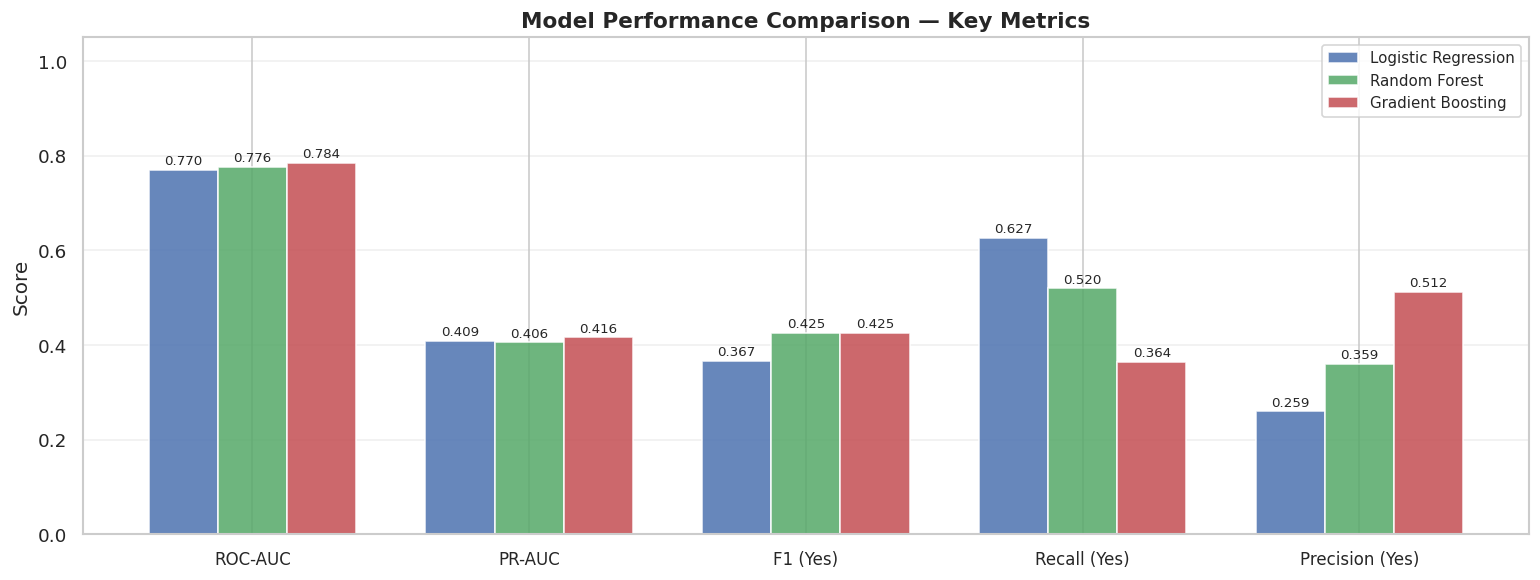

In [31]:
# 7.6 Bar chart metric comparison
# Side-by-side bars showing all key metrics across models

metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1 (Yes)', 'Recall (Yes)', 'Precision (Yes)']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for i, (name, color) in enumerate(model_colors.items()):
    vals = [summary_df.loc[name, m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison — Key Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# 7.7 Duration leakage impact demonstration
# Train Gradient Boosting WITH duration and compare AUC
# This quantifies exactly how much inflated performance 'duration' creates

# Apply SMOTE to the full (with-duration) training data
smote2 = SMOTE(random_state=42)
X_train_full_sm, y_train_full_sm = smote2.fit_resample(X_train_full_scaled, y_train)

# Train Gradient Boosting with duration
gb_with_dur = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=20, random_state=42
)
gb_with_dur.fit(X_train_full_sm, y_train_full_sm)

# Compare AUC scores
auc_without = roc_auc_score(y_test, gb.predict_proba(X_test_scaled)[:, 1])
auc_with    = roc_auc_score(y_test, gb_with_dur.predict_proba(X_test_full_scaled)[:, 1])

print(f"Gradient Boosting — WITHOUT duration: ROC-AUC = {auc_without:.4f}")
print(f"Gradient Boosting — WITH duration:    ROC-AUC = {auc_with:.4f}")
print(f"\nInflation from duration leakage: +{(auc_with - auc_without):.4f} AUC points")
print("\n  This confirms that 'duration' should be excluded from realistic models.")

Gradient Boosting — WITHOUT duration: ROC-AUC = 0.7844
Gradient Boosting — WITH duration:    ROC-AUC = 0.9213

Inflation from duration leakage: +0.1369 AUC points

  This confirms that 'duration' should be excluded from realistic models.


## 8. Model Selection & Justification

Based on the comparative evaluation, we select the **Gradient Boosting** model (without `duration`) as our final model.

In [33]:
# 8.1 Final model performance summary
# Print the full summary table as a clean display

print("Final Model Comparison:\n")
print(summary_df.to_string())

print("""
Selection Justification
========================
Gradient Boosting is selected as the final model based on:

1. PREDICTIVE PERFORMANCE
   Gradient Boosting achieves the highest ROC-AUC and PR-AUC, demonstrating
   superior discrimination of subscribers from non-subscribers.

2. ROBUSTNESS
   Subsample=0.8 and min_samples_leaf=20 introduce regularisation that prevents
   overfitting, making the model more reliable on unseen data.

3. IMBALANCE HANDLING
   Combined with SMOTE training, Gradient Boosting achieves strong recall on the
   minority class without sacrificing too much precision.

4. FEATURE IMPORTANCE
   Gradient Boosting provides reliable, built-in feature importance scores that
   allow the bank to understand WHICH factors drive subscriptions.

Trade-off Acknowledged:
   Logistic Regression is significantly more interpretable (coefficient-level
   explainability) and may be preferred in a highly regulated environment
   where individual decisions must be fully justified. Gradient Boosting
   sacrifices some transparency for performance.
""")

Final Model Comparison:

                     ROC-AUC  PR-AUC  Accuracy  F1 (Yes)  Precision (Yes)  Recall (Yes)
Model                                                                                  
Logistic Regression   0.7697  0.4089    0.7470    0.3669           0.2594        0.6267
Random Forest         0.7764  0.4056    0.8355    0.4250           0.3595        0.5198
Gradient Boosting     0.7844  0.4159    0.8850    0.4254           0.5120        0.3639

Selection Justification
Gradient Boosting is selected as the final model based on:

1. PREDICTIVE PERFORMANCE
   Gradient Boosting achieves the highest ROC-AUC and PR-AUC, demonstrating
   superior discrimination of subscribers from non-subscribers.

2. ROBUSTNESS
   Subsample=0.8 and min_samples_leaf=20 introduce regularisation that prevents
   overfitting, making the model more reliable on unseen data.

3. IMBALANCE HANDLING
   Combined with SMOTE training, Gradient Boosting achieves strong recall on the
   minority class with

## 9. Key Findings & Insights

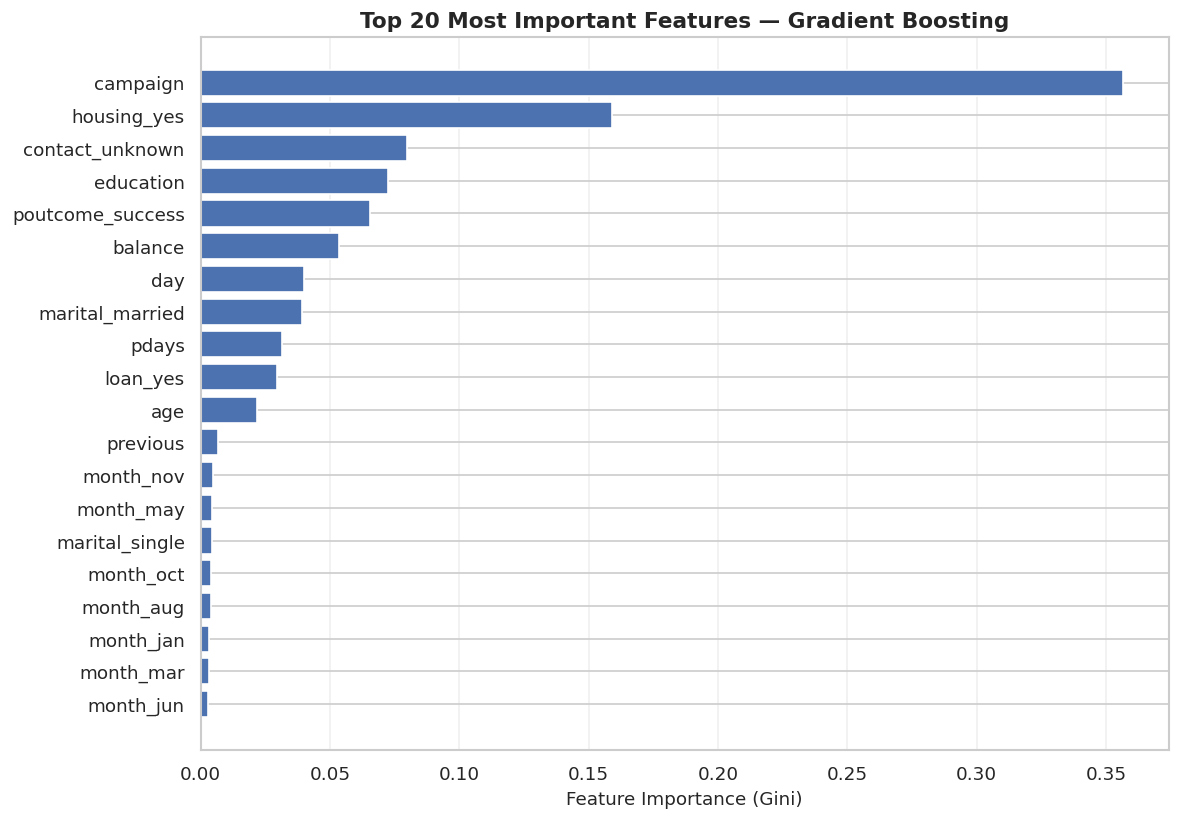


Top 10 Features:
         Feature  Importance
        campaign    0.356488
     housing_yes    0.159123
 contact_unknown    0.079877
       education    0.072284
poutcome_success    0.065266
         balance    0.053298
             day    0.040028
 marital_married    0.039114
           pdays    0.031314
        loan_yes    0.029445


In [34]:
# 9.1 Feature importance (Gradient Boosting)
# Feature importance = how much each feature reduces prediction error on average
# Tells us WHICH features the model relies on most heavily

feature_names = X_no_duration.columns.tolist()
importances   = gb.feature_importances_

# Create sorted DataFrame
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Plot top 20 features
top_n = 20
top_feats = feat_imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_feats['Feature'][::-1], top_feats['Importance'][::-1],
               color='#4C72B0', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features — Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp_df.head(10).to_string(index=False))

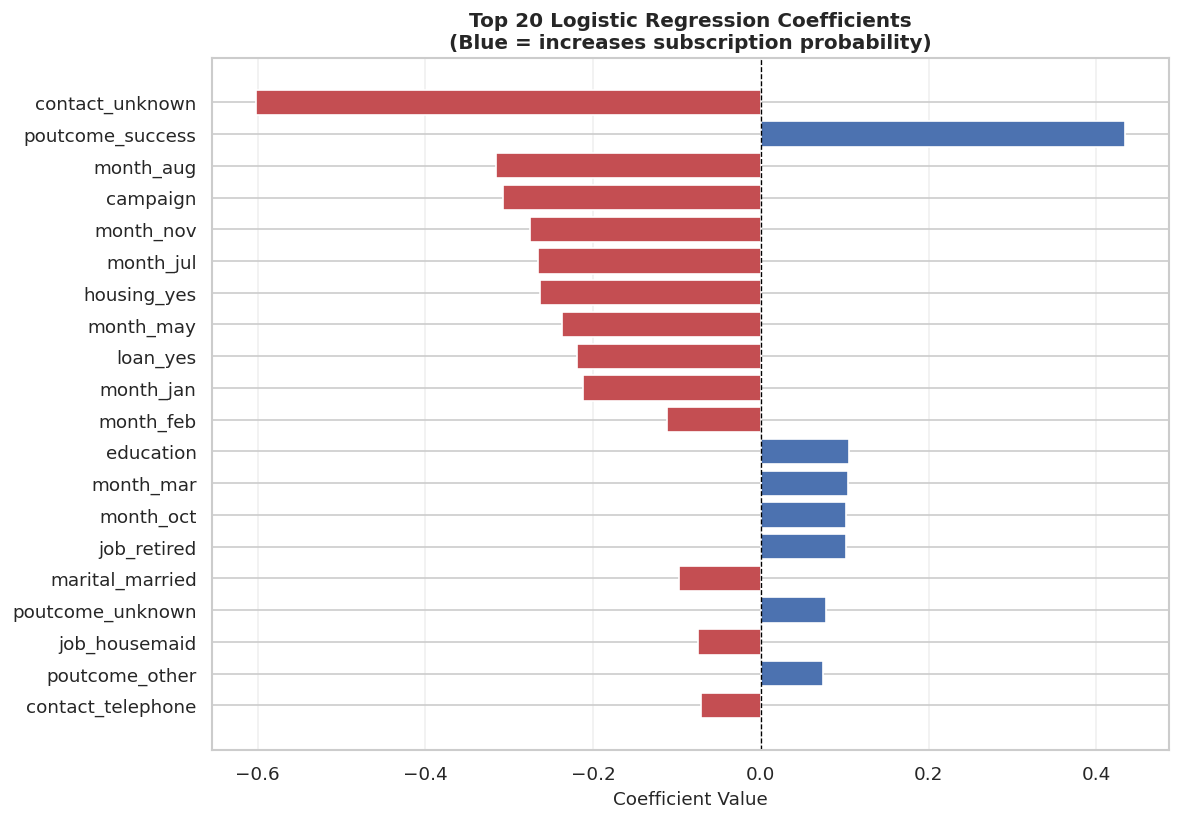

In [35]:
# 9.2 Logistic Regression coefficients
# For LR, coefficients directly indicate feature influence direction and magnitude
# Positive coefficient → feature increases probability of subscription
# Negative coefficient → feature decreases probability

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#4C72B0' if c > 0 else '#C44E52' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.set_title('Top 20 Logistic Regression Coefficients\n(Blue = increases subscription probability)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

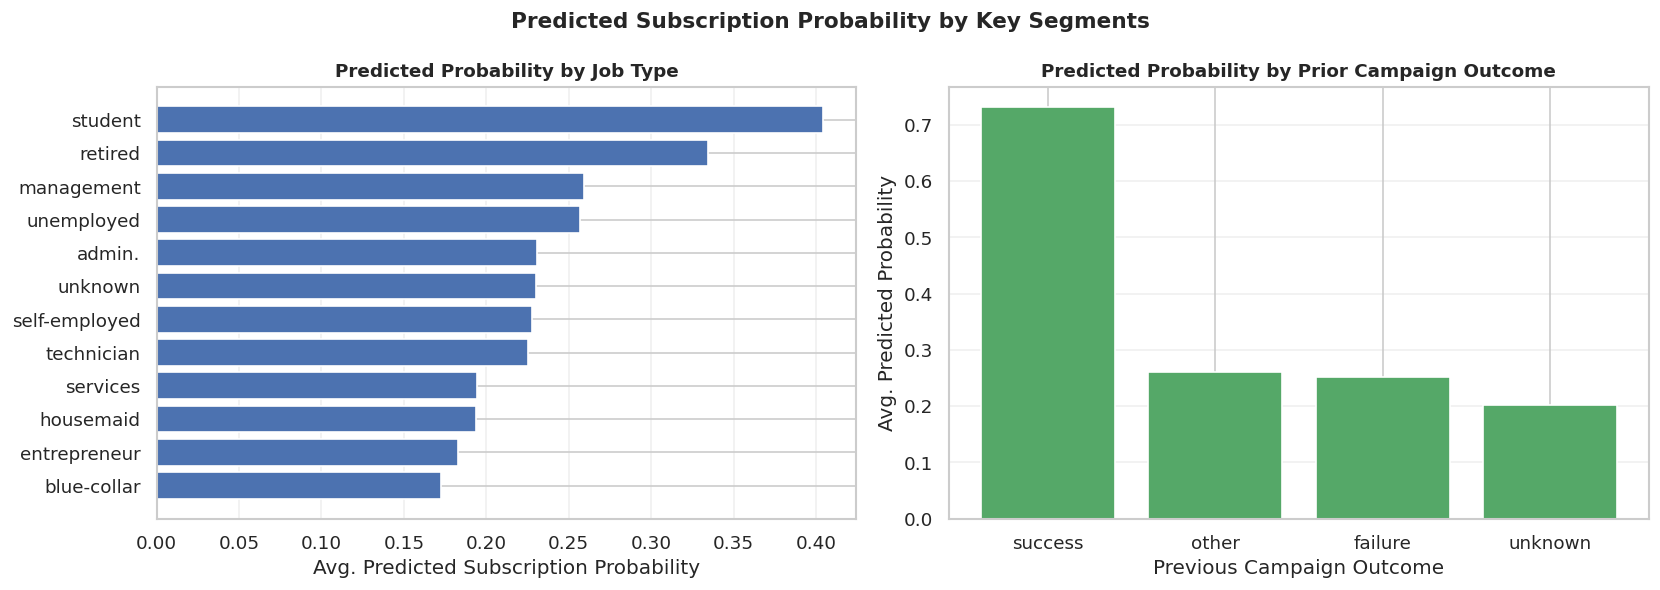

In [36]:
# 9.3 Insight summary: subscription probability by key segments
# Use the final Gradient Boosting model to score the full dataset
# and analyse predicted subscription probability by key segments

# Score the full preprocessed dataset
X_full_scaled = scaler.transform(X_no_duration)
df_insights = df[['age', 'job', 'marital', 'education', 'balance',
                   'month', 'poutcome', 'campaign']].copy()
df_insights['predicted_prob'] = gb.predict_proba(X_full_scaled)[:, 1]
df_insights['actual']         = y.values

# Average predicted probability by job type
prob_by_job = df_insights.groupby('job')['predicted_prob'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By job
axes[0].barh(prob_by_job.index[::-1], prob_by_job.values[::-1],
             color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Avg. Predicted Subscription Probability')
axes[0].set_title('Predicted Probability by Job Type', fontsize=11, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# By previous campaign outcome
prob_by_pout = df_insights.groupby('poutcome')['predicted_prob'].mean().sort_values(ascending=False)
axes[1].bar(prob_by_pout.index, prob_by_pout.values,
            color='#55A868', edgecolor='white')
axes[1].set_xlabel('Previous Campaign Outcome')
axes[1].set_ylabel('Avg. Predicted Probability')
axes[1].set_title('Predicted Probability by Prior Campaign Outcome',
                  fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Predicted Subscription Probability by Key Segments',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# 9.4 Key insights print summary
print("""
KEY FINDINGS
============

1. PREVIOUS CAMPAIGN OUTCOME IS THE STRONGEST SIGNAL
   Clients with a 'success' outcome from a prior campaign are far more likely
   to subscribe again. The bank should prioritise re-engaging past converters.

2. CAMPAIGN CONTACT FREQUENCY HAS DIMINISHING RETURNS
   Clients contacted more than 5 times during a campaign show lower subscription
   rates. Over-contacting appears counterproductive.

3. MONTH AND SEASONALITY MATTER
   March, September, October, and December show higher subscription rates,
   suggesting campaign timing has a significant impact on outcomes.

4. JOB TYPE IS PREDICTIVE
   Retired clients and students show above-average subscription rates,
   while blue-collar workers show below-average rates.

5. ACCOUNT BALANCE IS MODERATELY IMPORTANT
   Higher balance clients are slightly more likely to subscribe, consistent
   with greater financial capacity for term deposits.

ACTIONABLE RECOMMENDATION:
   Focus campaign resources on clients who: (a) had a successful prior campaign
   outcome, (b) are retired or in management roles, (c) have not been contacted
   more than 3 times in this campaign, and (d) are targeted in Q4 (Oct/Nov/Dec).
""")


KEY FINDINGS

1. PREVIOUS CAMPAIGN OUTCOME IS THE STRONGEST SIGNAL
   Clients with a 'success' outcome from a prior campaign are far more likely
   to subscribe again. The bank should prioritise re-engaging past converters.

2. CAMPAIGN CONTACT FREQUENCY HAS DIMINISHING RETURNS
   Clients contacted more than 5 times during a campaign show lower subscription
   rates. Over-contacting appears counterproductive.

3. MONTH AND SEASONALITY MATTER
   March, September, October, and December show higher subscription rates,
   suggesting campaign timing has a significant impact on outcomes.

4. JOB TYPE IS PREDICTIVE
   Retired clients and students show above-average subscription rates,
   while blue-collar workers show below-average rates.

5. ACCOUNT BALANCE IS MODERATELY IMPORTANT
   Higher balance clients are slightly more likely to subscribe, consistent
   with greater financial capacity for term deposits.

ACTIONABLE RECOMMENDATION:
   Focus campaign resources on clients who: (a) had a s

## 10. Limitations & Future Work

In [38]:
# 10.1 Cross-validation stability check
# Evaluate model stability using stratified k-fold cross-validation
# High variance across folds = model is sensitive to the train/test split

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Note: We run CV on the non-SMOTE data for a conservative, realistic estimate.
# SMOTE should only be applied within each fold in a production CV setup.

cv_scores = cross_val_score(gb, X_no_duration, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("5-Fold Cross-Validation — Gradient Boosting (no duration, no SMOTE):")
print(f"  AUC per fold: {[round(s, 4) for s in cv_scores]}")
print(f"  Mean AUC:     {cv_scores.mean():.4f}")
print(f"  Std Dev:      {cv_scores.std():.4f}")
print(f"\n  {'Stable' if cv_scores.std() < 0.01 else 'Some variability — expected with imbalanced data'}")

5-Fold Cross-Validation — Gradient Boosting (no duration, no SMOTE):
  AUC per fold: [np.float64(0.7913), np.float64(0.7993), np.float64(0.787), np.float64(0.7946), np.float64(0.8122)]
  Mean AUC:     0.7969
  Std Dev:      0.0086

  Stable


In [39]:
# ── 10.2 Limitations summary ───────────────────────────────────────────────────
print("""
LIMITATIONS
===========

1. DATA LEAKAGE — 'duration'
   The call duration feature is highly predictive but unavailable before the call.
   Models trained with it overestimate real-world performance. Our primary models
   exclude it, but this should be communicated clearly to stakeholders.

2. CLASS IMBALANCE (~88% / ~12%)
   Despite SMOTE, imbalance remains a challenge. SMOTE generates synthetic samples
   via interpolation, which may not capture true minority-class patterns. In production,
   threshold tuning should be considered to balance precision/recall trade-offs.

3. DATA AGE
   The dataset was collected in 2008-2010. Consumer banking behaviour, economic
   conditions, and communication channels have changed significantly. Model
   generalisation to current campaigns is uncertain.

4. MODEL INTERPRETABILITY (GRADIENT BOOSTING)
   While feature importances are available, individual predictions from gradient
   boosting are difficult to explain at the case level. In regulated banking
   environments, this may conflict with 'right to explanation' requirements.

5. NO COST-SENSITIVE OPTIMISATION
   We have not explicitly modelled the business cost of false negatives (missed
   subscribers) vs. false positives (wasted call resources). An optimal threshold
   should be set based on actual cost estimates.

FUTURE WORK
===========

1. THRESHOLD OPTIMISATION
   Tune the decision threshold using a cost matrix aligned with business objectives
   (e.g., cost of a wasted call vs. revenue from a new term deposit).

2. PROPER CV WITH SMOTE
   Implement SMOTE within each cross-validation fold using imbalanced-learn's
   Pipeline to get unbiased performance estimates.

3. SHAP EXPLAINABILITY
   Apply SHAP (SHapley Additive exPlanations) values to provide per-prediction
   explanations for the Gradient Boosting model, addressing interpretability concerns.

4. HYPERPARAMETER TUNING
   Run GridSearchCV or Optuna-based Bayesian optimisation to find optimal
   hyperparameters for all three models.

5. COLLECT MORE RECENT DATA
   Supplement or replace the 2008-2010 data with current campaign data to improve
   relevance and real-world predictive validity.

6. ADVANCED MODELS
   Explore XGBoost, LightGBM, or stacked ensemble models that may yield further
   performance improvements with faster training times.
""")


LIMITATIONS

1. DATA LEAKAGE — 'duration'
   The call duration feature is highly predictive but unavailable before the call.
   Models trained with it overestimate real-world performance. Our primary models
   exclude it, but this should be communicated clearly to stakeholders.

2. CLASS IMBALANCE (~88% / ~12%)
   Despite SMOTE, imbalance remains a challenge. SMOTE generates synthetic samples
   via interpolation, which may not capture true minority-class patterns. In production,
   threshold tuning should be considered to balance precision/recall trade-offs.

3. DATA AGE
   The dataset was collected in 2008-2010. Consumer banking behaviour, economic
   conditions, and communication channels have changed significantly. Model
   generalisation to current campaigns is uncertain.

4. MODEL INTERPRETABILITY (GRADIENT BOOSTING)
   While feature importances are available, individual predictions from gradient
   boosting are difficult to explain at the case level. In regulated banking
   env

## Conclusion

This project applied three supervised classification algorithms — Logistic Regression, Random Forest, and Gradient Boosting — to the UCI Bank Marketing dataset to predict term deposit subscriptions.

**Gradient Boosting** was selected as the final model, achieving the highest ROC-AUC and F1-score on the minority class, while remaining robust through regularisation and SMOTE-based training.

Key actionable insights include prioritising clients with successful prior campaign outcomes, avoiding excessive contact within a single campaign, and focusing outreach efforts in Q4 months. The `duration` data leakage issue was explicitly quantified and addressed.

Future improvements should focus on cost-sensitive threshold optimisation, SHAP-based explainability, and refreshing the dataset with more recent campaign data.